
=== kind=Strongly-convex, dim=500, gamma=1.0 ===
 running alpha=1.1 ... done
 running alpha=1.3 ... done
 running alpha=1.6 ... done
 running alpha=2.0 ... done

=== kind=Convex, dim=500, gamma=1.0 ===
 running alpha=1.1 ... done
 running alpha=1.3 ... done
 running alpha=1.6 ... done
 running alpha=2.0 ... done

=== kind=Non-convex, dim=500, gamma=1.0 ===
 running alpha=1.1 ... done
 running alpha=1.3 ... done
 running alpha=1.6 ... done
 running alpha=2.0 ... done

Experiment finished in 17.1s


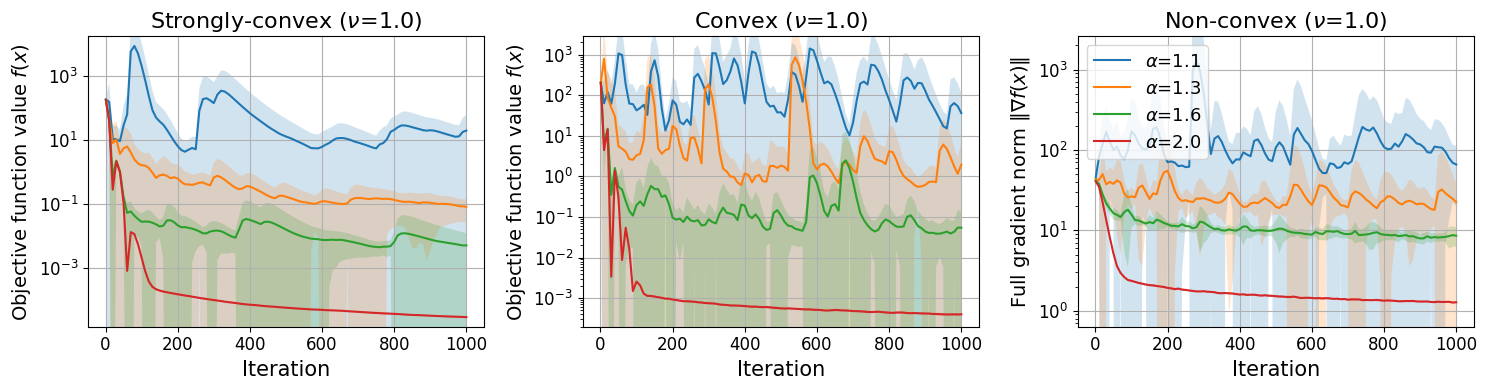

In [8]:
import numpy as np
import math
import matplotlib.pyplot as plt
from functools import partial
import time

def alpha_stable_rvs(alpha, size, scale=1.0, random_state=None):
    rng = np.random.default_rng(random_state)

    if alpha == 2.0:
        # Gaussian case: scale is treated as standard deviation
        return rng.normal(loc=0.0, scale=scale, size=size)

    if not (0.0 < alpha < 2.0):
        raise ValueError("alpha must satisfy 0 < alpha <= 2.0")

    # Inverse-uniform (two-sided Pareto-like). Use tiny eps to avoid exact u==0.
    eps = 1e-12
    signs = rng.choice([-1.0, 1.0], size=size)
    u = rng.uniform(0.0, 1.0, size=size)
    samples = signs * (u ** (-1.0 / alpha)) * scale
    return samples

def make_holder_objective(dim, nu, kind='convex', mu=1e-3, L=1.0):
    """
    Returns: f(x), grad_f(x)
    - dim: dimension
    - nu: holder exponent in (0,1] typically (but code accepts >0)
    - kind: 'strongly_convex', 'convex', 'nonconvex'
    - mu: strong-convexity parameter (used only for 'strongly_convex' if >0)
    """
    def phi_scalar(t):
        return (1.0 / (1.0 + nu)) * (np.abs(t) ** (1.0 + nu))
    def phi_grad_scalar(t):
        # derivative of phi wrt t: t * |t|^nu
        #return t * (np.abs(t) ** nu)
        return (np.abs(t) ** nu) * np.sign(t)

    if kind == 'Strongly-convex':
        # f(x) = mu/2 ||x||^2 + sum_i phi(x_i)
        def f(x):
            x = np.asarray(x)
            return 0.5 * mu * np.dot(x, x) + np.sum(phi_scalar(x))
        def grad(x):
            x = np.asarray(x)
            return mu * x + phi_grad_scalar(x)

    elif kind == 'Convex':
        # f(x) = sum_i phi(x_i)
        def f(x):
            x = np.asarray(x)
            return np.sum(phi_scalar(x))
        def grad(x):
            x = np.asarray(x)
            return phi_grad_scalar(x)

    elif kind == 'Non-convex':
        A = 0.5
        def f(x):
            x = np.asarray(x)
            return np.sum((1.0 / (1 + nu)) * (np.abs(x) ** (1 + nu)) - A * np.cos(2 * np.pi * x) + A)
        def grad(x):
            x = np.asarray(x)
            return 1.0 * (np.abs(x) ** nu) * np.sign(x) + A * 2 * np.pi * np.sin(2 * np.pi * x)
    else:
        raise ValueError("kind must be one of 'strongly_convex','convex','nonconvex'")
    return f, grad

def run_optimizer(grad_fn, f_fn, x0, steps=2000, lr=1e-3, alpha_noise=1.8, noise_scale=1e-2,
                  momentum=0.0, record_every=10, kind='convex', nu=0.5, mu=1e-3, seed=None):
    """
    Runs SGD-like update: compute full grad, add symmetric alpha-stable noise, then apply SGD or SGD+mom.
    Returns arrays of recorded objective values and iter indices.
    """
    rng = np.random.default_rng(seed)
    x = x0.astype(float).copy()
    v = np.zeros_like(x)
    records = []
    iters = []
    lr_max = lr
    if kind in ['Strongly-convex', 'Convex']:
      noise_scale = 0.01
    else:
      noise_scale = 0.1
    for t in range(1, steps+1):
        g = grad_fn(x)
        noise = alpha_stable_rvs(alpha_noise, size=x.shape, scale=noise_scale, random_state=rng)
        g_noisy = g + noise
        if kind in ['Strongly-convex']:
          lr = (2 * nu) / (mu * t)
        else:
          lr = lr_max * (t ** (-1.0 / (1.0 + nu)))

        if momentum > 0:
            #lr = lr_max
            v = momentum * v + (1-momentum) * g_noisy
            x = x - lr * v
        else:
            x = x - lr * g_noisy
        if (t % record_every) == 0 or t == 1:
          if kind == 'Non-convex':
            full_grad = grad_fn(x)
            records.append(np.linalg.norm(full_grad))
          else:
            records.append(float(f_fn(x)))
          iters.append(t)

    return np.array(iters), np.array(records)

def experiment(dim=20, nu=0.5, alpha_list=[1.2, 1.5, 1.8, 2.0],
               kinds=['Strongly-convex','Convex','Non-convex'], mu=1e-3,
               steps=2000, lr=1e-3, noise_scale=1e-2, momentum=0.0,
               trials=10, record_every=10, seed=0):
    rng = np.random.default_rng(seed)
    results = {}
    for kind in kinds:
        f, grad = make_holder_objective(dim=dim, nu=nu, kind=kind, mu=mu)
        results[kind] = {}
        print(f"\n=== kind={kind}, dim={dim}, nu={nu} ===")
        for alpha in alpha_list:
            print(f" running alpha={alpha} ...", end="", flush=True)
            all_runs = []
            for tr in range(trials):
                x0 = rng.normal(loc=0.0, scale=1.0, size=(dim,))
                iters, vals = run_optimizer(grad, f, x0, steps=steps, lr=lr,
                                            alpha_noise=alpha, noise_scale=noise_scale,
                                            momentum=momentum, record_every=record_every,
                                            kind=kind, nu=nu, mu=mu, seed=rng.integers(1<<30))
                all_runs.append(vals)
            all_runs = np.vstack(all_runs)  # trials x len(record)
            mean_vals = all_runs.mean(axis=0)
            median_vals = np.median(all_runs, axis=0)
            p25 = np.percentile(all_runs, 25, axis=0)
            p75 = np.percentile(all_runs, 75, axis=0)

            std_vals = all_runs.std(axis=0)
            results[kind][alpha] = {
                'iters': iters,
                'mean': mean_vals,
                'median': median_vals,
                'p25': p25,
                'p75': p75,
                'std': std_vals,
                'raw': all_runs
            }
            print(" done")
    return results

def plot_results(results, kind, ax=None, title=None, logy=True, plot='mean'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    all_means = []

    for alpha, info in sorted(results[kind].items(), key=lambda x: x[0]):
        it = info['iters']
        mean = info['mean']
        std = info['std']
        median = info['median']
        p25 = info['p25']
        p75 = info['p75']
        all_means.append(mean)

        label = fr"$\alpha$={alpha}"
        if logy:
          if plot == 'mean':
            ax.semilogy(it, mean, label=label)
            ax.fill_between(it, np.maximum(mean-std, 1e-16), mean+std, alpha=0.2)
          else:
            ax.semilogy(it, median, label=label)
            ax.fill_between(it, p25, p75, alpha=0.2)
        else:
          if plot == 'mean':
            ax.plot(it, mean, label=label)
            ax.fill_between(it, mean-std, mean+std, alpha=0.2)
          else:
            ax.plot(it, median, label=label)
            ax.fill_between(it, p25, p75, alpha=0.2)

    global_mean_max = np.max([np.max(m) for m in all_means])
    global_mean_min = np.min([np.min(m) for m in all_means])

    if logy:
          ax.set_ylim(bottom=np.maximum(global_mean_min * 0.5, 1e-12),
                      top=global_mean_max * 2.0)
    else:
          ax.set_ylim(0, global_mean_max * 1.2)
    ax.set_xlabel("Iteration", fontsize=15)
    if kind == 'Non-convex':
        ax.set_ylabel(r"Full gradient norm $\|\nabla f(x)\|$", fontsize=14)
    else:
        ax.set_ylabel("Objective function value $f(x)$", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title(title, fontsize=16)
    if kind == 'Non-convex':
      ax.legend(
            fontsize=13,
            ncol=1,
            loc='best'
      )
    ax.grid(True)
    return ax

if __name__ == "__main__":
    dim = 500                # problem dimension
    nu = 1.0              # Holder exponent (try 0.1, 0.3, 0.6, 1.0)
    alpha_list = [1.1, 1.3, 1.6, 2.0]  # tail indices to compare
    kinds = ['Strongly-convex', 'Convex', 'Non-convex']
    mu = 1.0
    steps = 1000
    lr = 1.0
    noise_scale = 0.01
    momentum = 0.9         # set 0.0 for plain SGD
    trials = 20
    record_every = 10
    seed = 42
    plot = 'mean'
    # =============================
    t0 = time.time()
    results = experiment(dim=dim, nu=nu, alpha_list=alpha_list,
                         kinds=kinds, mu=mu, steps=steps, lr=lr, noise_scale=noise_scale,
                         momentum=momentum, trials=trials, record_every=record_every,
                         seed=seed)
    t1 = time.time()
    print(f"\nExperiment finished in {t1-t0:.1f}s")
    # Plot results per kind
    fig, axes = plt.subplots(1, len(kinds), figsize=(5*len(kinds),4))
    for i, k in enumerate(kinds):
        plot_results(results, k, ax=axes[i], title=fr"{k} ($\nu$={nu})", logy=True, plot=plot)
    plt.tight_layout()
    #plt.show()
    plt.savefig(f'beta={momentum},nu={nu}.pdf', dpi=800)


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import time

def alpha_stable_rvs(alpha, size, scale=1.0, rng=None):
    if rng is None: rng = np.random.default_rng()
    if alpha == 2.0: return rng.normal(loc=0.0, scale=scale, size=size)
    eps = 1e-12
    signs = rng.choice([-1.0, 1.0], size=size)
    u = rng.uniform(0.0, 1.0, size=size)
    return signs * (u ** (-1.0 / alpha)) * scale

class HolderObjective:
    def __init__(self, kind, nu, mu=1.0, A=0.5):
        self.kind = kind
        self.nu = nu
        self.mu = mu
        self.A = A

    def f(self, x):
        phi = (1.0 / (1.0 + self.nu)) * (np.abs(x) ** (1.0 + self.nu))
        if self.kind == 'Strongly-convex':
            return 0.5 * self.mu * np.dot(x, x) + np.sum(phi)
        elif self.kind == 'Convex':
            return np.sum(phi)
        else: # Non-convex
            return np.sum(phi - self.A * np.cos(2 * np.pi * x) + self.A)

    def grad(self, x):
        g_phi = (np.abs(x) ** self.nu) * np.sign(x)
        if self.kind == 'Strongly-convex':
            return self.mu * x + g_phi
        elif self.kind == 'Convex':
            return g_phi
        else: # Non-convex
            return g_phi + self.A * 2 * np.pi * np.sin(2 * np.pi * x)

def run_grid_simulation(kind, nu, alpha, dim=500, steps=4000, lr_max=1.0, momentum=0.9, rng=None):
    obj = HolderObjective(kind, nu)
    x = rng.normal(loc=0.0, scale=1.0, size=(dim,))
    xx = x.astype(float).copy()
    v = np.zeros_like(xx)

    noise_scale = 0.1 if kind == 'Non-convex' else 0.01

    for t in range(1, steps + 1):
        g = obj.grad(x)
        noise = alpha_stable_rvs(alpha, size=x.shape, scale=noise_scale, rng=rng)
        g_noisy = g + noise

        if kind == 'Strongly-convex':
            lr = (2 * nu) / (obj.mu * t)
        else:
            lr = lr_max * (t ** (-1.0 / (1.0 + nu)))

        if momentum > 0:
            #lr = lr_max
            v = momentum * v + (1-momentum) * g_noisy
            x = x - lr * v
        else:
            x = x - lr * g_noisy

    if kind == 'Non-convex':
        return np.linalg.norm(obj.grad(x))
    else:
        return obj.f(x)

def save_experiment_data(kind='Non-convex', filename=None):
    nus = np.linspace(0.1, 1.0, 10)
    alphas = np.linspace(1.1, 2.0, 10)
    trials = 20
    dim = 500
    momentum = 0.0
    steps = 4000

    heatmap_data = np.zeros((len(nus), len(alphas)))
    rng = np.random.default_rng(42)

    print(f"Starting Grid Experiment: [{kind}]")
    start_t = time.time()

    for i, g_val in enumerate(nus):
        for j, a_val in enumerate(alphas):
            res_list = [run_grid_simulation(kind, g_val, a_val, dim=dim, steps=steps, momentum=momentum, rng=rng) for _ in range(trials)]
            heatmap_data[i, j] = np.mean(res_list)
        print(f"Progress: nu={g_val:.1f} done")

    if filename is None:
        filename = f"{kind},beta={momentum}.npz"

    np.savez(filename, data=heatmap_data, nus=nus, alphas=alphas, kind=kind)
    print(f"Saved results to {filename} (Time: {time.time()-start_t:.1f}s)")

save_experiment_data(kind='Non-convex')

Starting Grid Experiment: [Non-convex]
Progress: gamma=0.1 done
Progress: gamma=0.2 done
Progress: gamma=0.3 done
Progress: gamma=0.4 done
Progress: gamma=0.5 done
Progress: gamma=0.6 done
Progress: gamma=0.7 done
Progress: gamma=0.8 done
Progress: gamma=0.9 done
Progress: gamma=1.0 done
Saved results to Non-convex,beta=0.0.npz (Time: 2.3s)


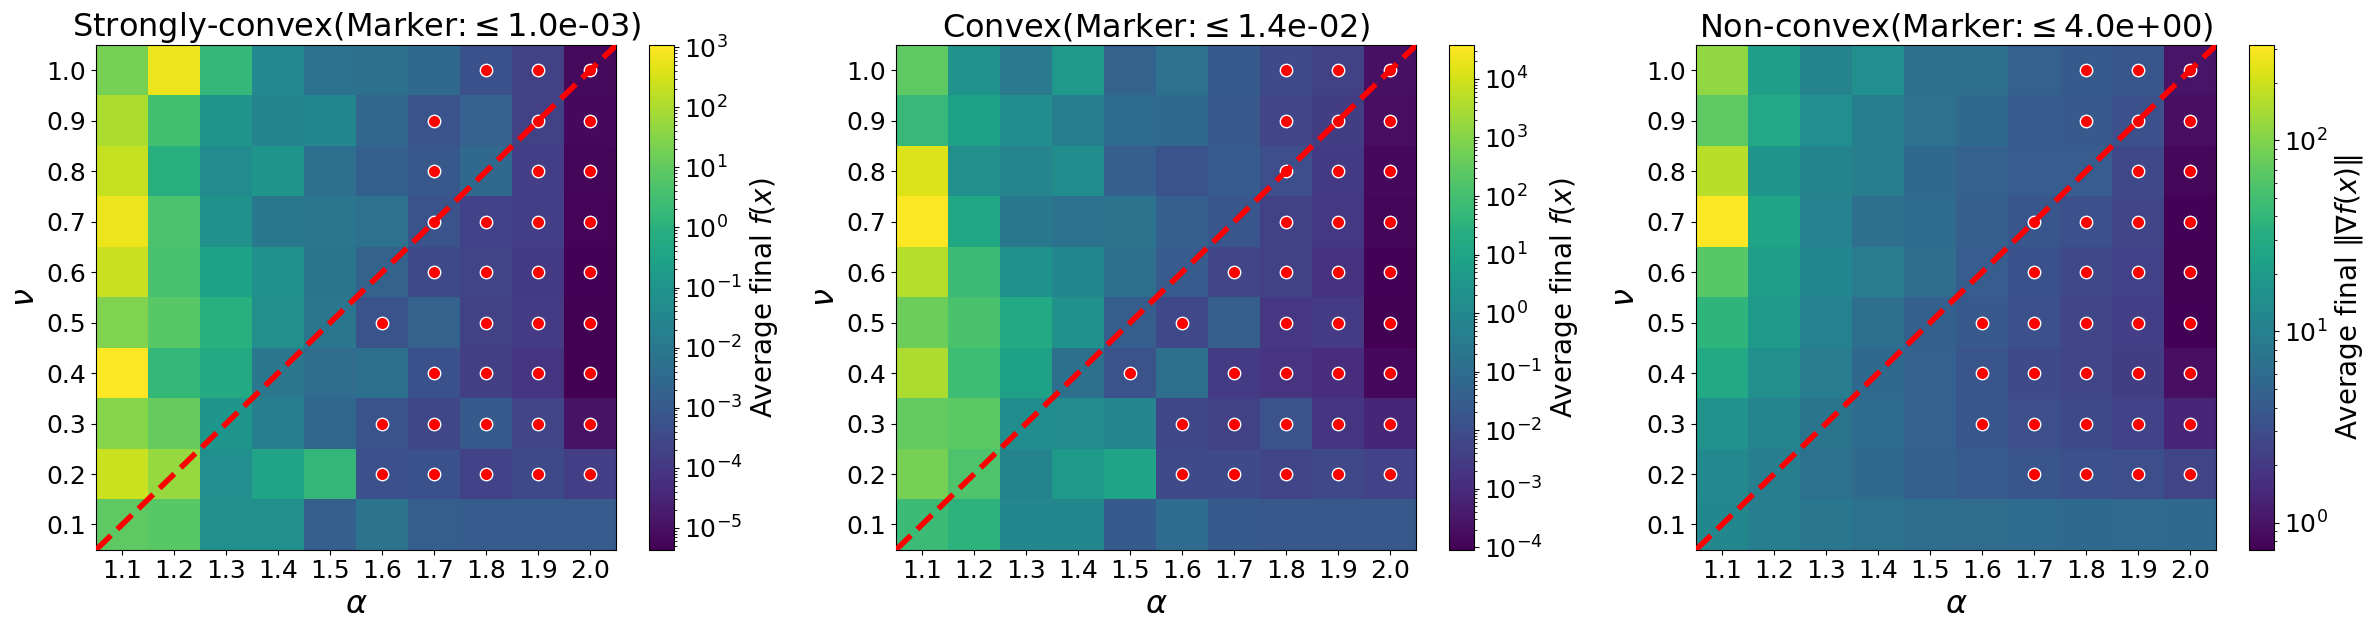

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os

def plot_three_heatmaps(filenames, save_name="heatmaps_Momentum.pdf", top_percent=20):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6.4))

    for i, filename in enumerate(filenames):
        if not os.path.exists(filename):
            print(f"Error: {filename} not found.")
            continue

        loader = np.load(filename)
        data = loader['data']
        nus = loader['nus']
        alphas = loader['alphas']
        kind = str(loader['kind'])
        ax = axes[i]

        label_str = r"$\|\nabla f(x)\|$" if kind == 'Non-convex' else r"$f(x)$"

        pcm = ax.pcolormesh(alphas, nus, data,
                             norm=colors.LogNorm(vmin=data.min(), vmax=data.max()),
                             cmap='viridis', shading='auto')

        threshold = np.percentile(data, top_percent)
        y_indices, x_indices = np.where(data <= threshold)

        marker_alphas = alphas[x_indices]
        marker_nus = nus[y_indices]

        ax.scatter(marker_alphas, marker_nus,
                    color='red', marker='o', s=80, edgecolors='white', zorder=5)

        ax.plot([alphas.min()-0.05, alphas.max()+0.05], [nus.min()-0.05, nus.max()+0.05],
                color='red', linestyle='--', linewidth=4, zorder=6)


        ax.set_xlabel(r"$\alpha$", fontsize=23)
        ax.set_ylabel(r"$\nu$", fontsize=23)
        ax.set_title(fr"{kind}(Marker:$\leq${threshold:.1e})", fontsize=23)

        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label(f"Average final {label_str}", fontsize=20)
        cbar.ax.tick_params(labelsize=18)

        ax.set_xticks(alphas[::1])
        ax.set_yticks(nus[::1])
        ax.tick_params(axis='both', labelsize=18)

    plt.tight_layout()

    plt.savefig(save_name, dpi=800)
    plt.show()

files = [
    "Strongly-convex,beta=0.0.npz",
    "Convex,beta=0.0.npz",
    "Non-convex,beta=0.0.npz"
]
plot_three_heatmaps(files, save_name="heatmaps_SGD.pdf", top_percent=35)